Exploring images in the dataset

In [1]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [26]:
def inspect_image_properties(image_path, is_label_mask=False):
    # Open the image
    image = Image.open(image_path)

    # Convert to greyscale if it is a label mask
    if is_label_mask:
        image = image.convert("L")
        image = image.point(lambda p: 255 if p == 255 else 0)

    # Display the image in the notebook
    plt.imshow(np.array(image), cmap="gray" if is_label_mask else None)
    plt.axis("off")  # Hide axes
    plt.show()

    # Inspect the most important properties
    print("Image Format:", image.format)
    print("Image Size:", image.size)  # (width, height)
    print("Image Mode:", image.mode)
    print("Image Width:", image.width)
    print("Image Height:", image.height)

    # Check if the image has an alpha channel
    if "A" in image.getbands():
        print("The image has an alpha channel (transparency).")
    else:
        print("The image does not have an alpha channel.")

    # Display additional info if available
    print("Image Info:", image.info)

    # Show the range of pixel values for each of the R, G, B channels
    image_array = np.array(image)
    if image.mode == "RGB":
        print(
            "Range of pixel values for R channel:",
            image_array[:, :, 0].min(),
            "-",
            image_array[:, :, 0].max(),
        )
        print(
            "Range of pixel values for G channel:",
            image_array[:, :, 1].min(),
            "-",
            image_array[:, :, 1].max(),
        )
        print(
            "Range of pixel values for B channel:",
            image_array[:, :, 2].min(),
            "-",
            image_array[:, :, 2].max(),
        )
    elif image.mode == "RGBA":
        print(
            "Range of pixel values for R channel:",
            image_array[:, :, 0].min(),
            "-",
            image_array[:, :, 0].max(),
        )
        print(
            "Range of pixel values for G channel:",
            image_array[:, :, 1].min(),
            "-",
            image_array[:, :, 1].max(),
        )
        print(
            "Range of pixel values for B channel:",
            image_array[:, :, 2].min(),
            "-",
            image_array[:, :, 2].max(),
        )
        print(
            "Range of pixel values for A channel:",
            image_array[:, :, 3].min(),
            "-",
            image_array[:, :, 3].max(),
        )
    elif image.mode == "L":
        print("Range of pixel values:", image_array.min(), "-", image_array.max())
    else:
        print("Image mode is not RGB, RGBA, or L, cannot display pixel value ranges.")

    # Print unique pixel values and their counts
    unique, counts = np.unique(
        image_array.reshape(-1, image_array.shape[-1] if image_array.ndim == 3 else 1),
        axis=0,
        return_counts=True,
    )
    print("Unique pixel values and their counts:")
    for pixel_value, count in zip(unique, counts):
        print(f"Pixel value: {pixel_value}, Count: {count}")

Paths to images and labels

In [22]:
project_path = Path(
    r"C:\Users\TFH\NGI\Jessica Ka Yi Chiu - Paper - Synthetic rock joint generation for ML"
)
path_images = Path(project_path, "Data/rockmass")
path_labels = Path(project_path, "Data/label")
image_path_synthetic_box = Path(path_images, "Benchmark-cliff_side-0.png")
label_path_synthetic_box = Path(path_labels, "Benchmark-cliff_side-0.png")

image_path_synthetic_rock_slope = Path(path_images, "Larvik-3.png")
label_path_synthetic_rock_slope = Path(path_labels, "Larvik-3.png")

image_path_synthetic_rock_slope2 = Path(path_images, "Rv4_P1700-1900-0.png")
label_path_synthetic_rock_slope2 = Path(path_labels, "Rv4_P1700-1900-0.png")

image_path_synthetic_box.exists(), label_path_synthetic_box.exists()

(True, True)

Inspect images and labels

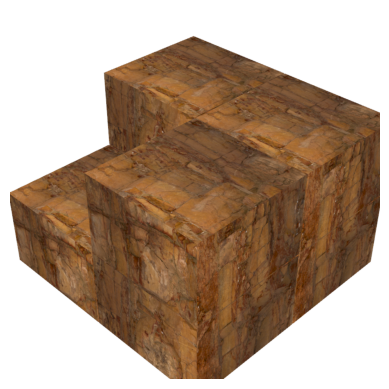

Image Format: PNG
Image Size: (800, 800)
Image Mode: RGB
Image Width: 800
Image Height: 800
The image does not have an alpha channel.
Image Info: {'srgb': 0, 'gamma': 0.45455, 'dpi': (71.9836, 71.9836)}
Range of pixel values for R channel: 43 - 255
Range of pixel values for G channel: 20 - 255
Range of pixel values for B channel: 0 - 255
Unique pixel values and their counts:
Pixel value: [43 20  0], Count: 3
Pixel value: [43 28  0], Count: 1
Pixel value: [43 28 20], Count: 2
Pixel value: [46 20  0], Count: 2
Pixel value: [46 20 20], Count: 1
Pixel value: [46 28  0], Count: 6
Pixel value: [46 28 20], Count: 8
Pixel value: [46 34  0], Count: 1
Pixel value: [50 28  0], Count: 13
Pixel value: [50 28 20], Count: 7
Pixel value: [50 34  0], Count: 4
Pixel value: [50 34 20], Count: 10
Pixel value: [50 34 28], Count: 6
Pixel value: [50 39 20], Count: 1
Pixel value: [53 20  0], Count: 3
Pixel value: [53 28  0], Count: 11
Pixel value: [53 28 20], Count: 4
Pixel value: [53 34  0], Count: 9
Pixel v

In [23]:
inspect_image_properties(image_path_synthetic_box)

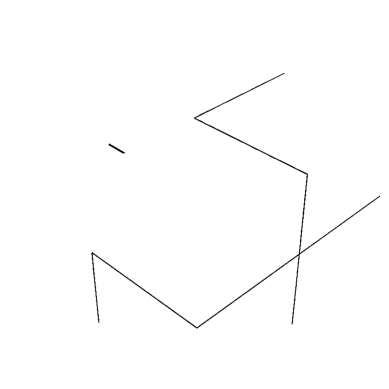

Image Format: None
Image Size: (800, 800)
Image Mode: L
Image Width: 800
Image Height: 800
The image does not have an alpha channel.
Image Info: {'srgb': 0, 'gamma': 0.45455, 'dpi': (71.9836, 71.9836)}
Range of pixel values: 0 - 255
Unique pixel values and their counts:
Pixel value: [0], Count: 4112
Pixel value: [255], Count: 635888


In [29]:
inspect_image_properties(label_path_synthetic_box, is_label_mask=True)

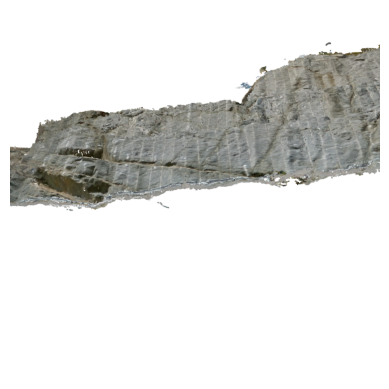

Image Format: PNG
Image Size: (800, 800)
Image Mode: RGB
Image Width: 800
Image Height: 800
The image does not have an alpha channel.
Image Info: {'srgb': 0, 'gamma': 0.45455, 'dpi': (71.9836, 71.9836)}
First 5 rows of numeric values in the image:
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [133 138 131]
  [152 151 146]
  [161 162 156]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [128 134 128]
  [148 153 147]
  [151 156 152]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [114 120 116]
  [135 140 134]
  [142 147 141]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [124 129 124]
  [131 136 130]
  [145 149 145]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [136 141 135]
  [141 144 139]
  [142 144 141]]]


In [10]:
inspect_image_properties(image_path_synthetic_rock_slope)

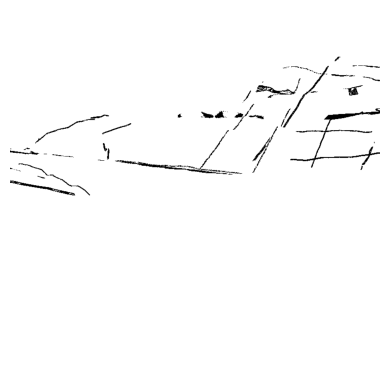

Image Format: None
Image Size: (800, 800)
Image Mode: L
Image Width: 800
Image Height: 800
The image does not have an alpha channel.
Image Info: {'srgb': 0, 'gamma': 0.45455, 'dpi': (71.9836, 71.9836)}
Range of pixel values: 0 - 255
Unique pixel values and their counts:
Pixel value: [0], Count: 9144
Pixel value: [255], Count: 630856


In [31]:
inspect_image_properties(label_path_synthetic_rock_slope, is_label_mask=True)

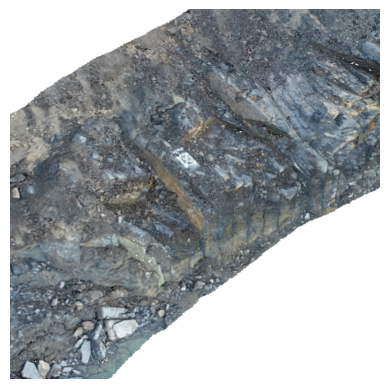

Image Format: PNG
Image Size: (800, 800)
Image Mode: RGB
Image Width: 800
Image Height: 800
The image does not have an alpha channel.
Image Info: {'srgb': 0, 'gamma': 0.45455, 'dpi': (71.9836, 71.9836)}


In [31]:
inspect_image_properties(image_path_synthetic_rock_slope2)

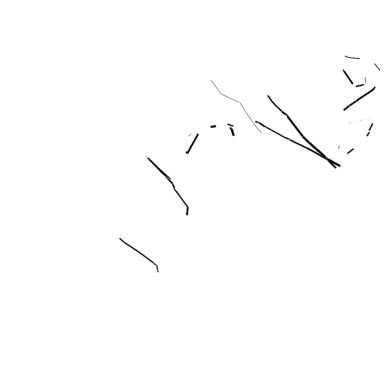

Image Format: PNG
Image Size: (800, 800)
Image Mode: RGB
Image Width: 800
Image Height: 800
The image does not have an alpha channel.
Image Info: {'srgb': 0, 'gamma': 0.45455, 'dpi': (71.9836, 71.9836)}
Range of pixel values for R channel: 0 - 255
Range of pixel values for G channel: 0 - 255
Range of pixel values for B channel: 0 - 255
Unique pixel values and their counts:
Pixel value: [0 0 0], Count: 2727
Pixel value: [1 1 1], Count: 39
Pixel value: [2 2 2], Count: 25
Pixel value: [3 3 3], Count: 11
Pixel value: [4 4 4], Count: 20
Pixel value: [5 5 5], Count: 18
Pixel value: [6 6 6], Count: 12
Pixel value: [7 7 7], Count: 13
Pixel value: [8 8 8], Count: 11
Pixel value: [9 9 9], Count: 12
Pixel value: [10 10 10], Count: 14
Pixel value: [11 11 11], Count: 16
Pixel value: [12 12 12], Count: 14
Pixel value: [13 13 13], Count: 7
Pixel value: [14 14 14], Count: 10
Pixel value: [15 15 15], Count: 8
Pixel value: [16 16 16], Count: 9
Pixel value: [17 17 17], Count: 5
Pixel value: [18 18 18], C

In [19]:
inspect_image_properties(label_path_synthetic_rock_slope2)